# MDR-TS v3.3
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v3.3
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**
- Experimenting with tunning the model:
  - Shallower trees
  - Stronger L2
  - Higher min_child_weight
  - Subsample tuned for drift

For other info see `MDR-TS-v1.0`

## 0. Imports

In [1]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting (baseline model)
import xgboost as xgb
from xgboost import XGBRegressor

# PyTorch
import torch

# SHAP
import shap

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Utilities
from itertools import product
from tqdm.auto import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

np.random.seed(0)
plt.rcParams["figure.dpi"] = 120

imports loaded
using: cpu


## 1. Environment Setup

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [3]:
# Project paths
VERSION = "v3"
SUBVERSION = "v3.3"
RUN_NAME = "mdr_ts_v3_3"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR/"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR/
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.3

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_all/train_derived_all.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_all/val_derived_all.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_all/test_derived_all.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/train_derived_all.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/val_derived_all.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/test_derived_all.csv
train: dropped columns ['slope', 'elev']

train: shape=(15904, 352)
train: columns=352
val: dropped columns ['slope', 'elev']

val: shape=(3408, 352)
val: columns=352
test: dropped columns ['slope', 'elev']

test: shape=(3408, 352)
test: columns=352


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 352

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY', 'soil_moisture_5cm', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1', 'A_d_G_API_kobs2', 'A_d_G_API_kobs5', 'A_d_G_API_kobs7', 'A_d_G_API_kobs14']


## 4. Data Sanity Checks

In [6]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    'A_d_E_SAR_ratio_kobs1',
    'A_d_F_NDMI_kobs1',
    'A_d_G_API_kobs1',
    'A_d_LST_modis_kobs1',
    'C_smm_E_SAR_ratio_alpha0.85_n5',
    'C_smm_F_NDMI_alpha0.85_n5',
    'C_smm_G_API_alpha0.85_n5',
    'C_smm_LST_modis_alpha0.85_n5',
    'DOY',
    'D_sa_E_SAR_ratio',
    'D_sa_F_NDMI',
    'D_sa_LST_modis',
    'D_z_E_SAR_ratio',
    'D_z_F_NDMI',
    'D_z_LST_modis',
    'E_SAR_diff',
    'E_SAR_ratio',
    'F_MSI',
    'F_NDMI',
    'F_NDVI',
    'G_API',
    'G_DSLR',
    'G_DSLR_isnan',
    'G_rain_sum_30d',
    'G_rain_sum_3d',
    'G_rain_sum_7d',
    # 'I_ts_spike_s1_vv', # removed due to leakage concerns
    'LST_modis',
    'V_rollstd_E_SAR_ratio_kobs7',
    'V_rollstd_F_NDMI_kobs7',
    'V_rollstd_G_API_kobs7',
    'V_rollstd_LST_modis_kobs7',
    'aspect',
    'precip_mm',
    's1_vh',
    's1_vv',
    's2_b11',
    's2_b12',
    's2_b4',
    's2_b8'
]

# quick validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 39
  Target:   soil_moisture_5cm


In [7]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[OK] station Touchet_WA_824: train<valval<test with no date overlap

[INFO] No temporal leakage detected.


In [8]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-08-17 00:00:00
    val   min date: 2021-08-18 00:00:00
  Station Quinault:
    train max date: 2021-09-03 00:00:00
    val   min date: 2021-09-04 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-05-13 00:00:00
    val   min date: 2021-05-14 00:00:00
  Station Spokane:
    train max date: 2021-09-19 00:00:00
    val   min date: 2021-09-20 00:00:00
  Station Touchet_WA_824:
    train max date: 2018-06-07 00:00:00
    val   min date: 2018-06-08 00:00:00


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     15904
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-19 00:00:00

VAL
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2018-06-08 00:00:00 -- 2023-12-29 00:00:00

TEST
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2019-11-12 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [10]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (15904, 39)
  X_val:   (3408, 39)
  X_test:  (3408, 39)
  y_train: (15904,)


### 6.2 Feature Overview

In [11]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
C_smm_G_API_alpha0.85_n5,1.398499e+02,160.921738,0.000000,1168.583344
G_rain_sum_30d,1.338338e+02,149.349569,0.000000,1100.500000
DOY,1.850239e+02,103.325581,1.000000,366.000000
G_API,4.437373e+01,51.814489,0.000000,408.757381
G_rain_sum_7d,3.523672e+01,49.781450,0.000000,477.000000
C_smm_LST_modis_alpha0.85_n5,9.056506e+02,42.208171,0.000000,997.283054
G_rain_sum_3d,1.770443e+01,28.967554,0.000000,259.400000
aspect,1.643586e+02,13.975917,142.090762,183.089635
LST_modis,2.875445e+02,11.502918,248.913937,316.363128
precip_mm,4.440726e+00,9.805408,0.000000,127.600000


### 6.3 Feature Correlation

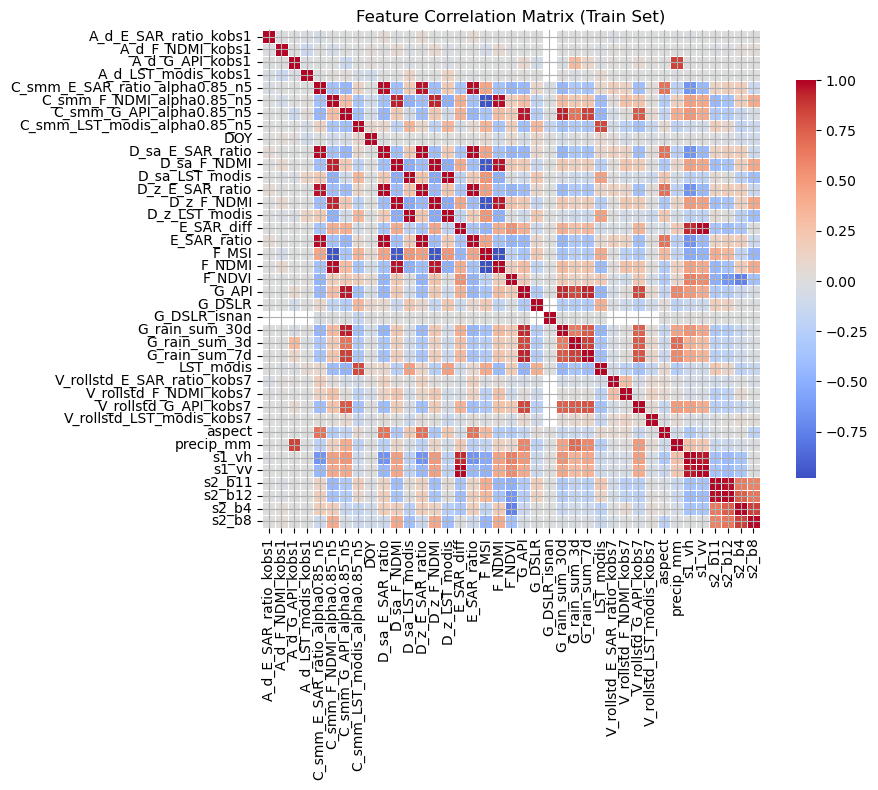

In [12]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

## 7. Training Loop

### 7.1 Fit Model & Find Best Hyperparameters

In [13]:
def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)

param_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [5, 20, 50, 100],
    "lambda": [1, 5, 10, 30],            # reg_lambda in train API is 'lambda'
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

seeds = [0, 1, 2]
rows = []

BASE = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,              # learning_rate
    "gamma": 0.0,
    "alpha": 0.0,             # reg_alpha
    "verbosity": 0,
}

NUM_BOOST_ROUND = 5000
EARLY_STOP = 50

In [14]:
grid = list(product(*param_grid.values()))

pbar = tqdm(grid, desc="XGB grid search", total=len(grid))
best_so_far = -np.inf

for vals in pbar:
    params = dict(zip(param_grid.keys(), vals))

    scores = []
    for s in seeds:
        p = dict(BASE)
        p.update(params)
        p["seed"] = s

        booster = xgb.train(
            params=p,
            dtrain=dtrain,
            num_boost_round=NUM_BOOST_ROUND,
            evals=[(dtrain, "train"), (dval, "val")],
            early_stopping_rounds=EARLY_STOP,
            verbose_eval=False,
        )

        yv = booster.predict(
            dval,
            iteration_range=(0, booster.best_iteration + 1)
        )

        scores.append((
            r2_score(y_val, yv),
            rmse(y_val, yv),
            float(np.mean(y_val.values - yv)),
            booster.best_iteration
        ))

    r2s = [x[0] for x in scores]
    rmses = [x[1] for x in scores]
    biases = [x[2] for x in scores]
    best_iters = [x[3] for x in scores]

    mean_r2 = float(np.mean(r2s))

    rows.append({
        "max_depth": params["max_depth"],
        "min_child_weight": params["min_child_weight"],
        "lambda": params["lambda"],
        "subsample": params["subsample"],
        "colsample_bytree": params["colsample_bytree"],
        "val_R2_mean": mean_r2,
        "val_R2_std":  float(np.std(r2s)),
        "val_RMSE_mean": float(np.mean(rmses)),
        "val_bias_mean": float(np.mean(biases)),
        "best_iter_mean": float(np.mean(best_iters)),
    })

    if mean_r2 > best_so_far:
        best_so_far = mean_r2
        pbar.set_postfix(best_val_R2=f"{best_so_far:.4f}")

XGB grid search:   0%|          | 0/576 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results = pd.DataFrame(rows).sort_values(["val_R2_mean", "val_R2_std"], ascending=[False, True])
results.head(15)

,max_depth,min_child_weight,lambda,subsample,colsample_bytree,val_R2_mean,val_R2_std,val_RMSE_mean,val_bias_mean,best_iter_mean
177,3,5,30,1.0,0.6,0.791562,0.000000e+00,0.049048,0.009260,337.000000
405,4,100,5,0.6,0.6,0.791069,6.681741e-04,0.049106,0.009724,183.666667
441,5,5,5,0.6,0.6,0.790956,1.945833e-03,0.049118,0.009589,109.333333
387,4,50,30,0.6,0.6,0.790776,2.873123e-03,0.049139,0.010004,246.333333
429,4,100,30,1.0,0.6,0.790535,1.110223e-16,0.049168,0.009622,169.000000
315,4,5,30,0.6,0.6,0.790349,2.216468e-03,0.049190,0.009844,274.333333
267,3,100,5,1.0,0.6,0.790228,0.000000e+00,0.049204,0.009867,296.000000
159,3,5,5,1.0,0.6,0.790193,0.000000e+00,0.049208,0.009999,318.000000
351,4,20,30,0.6,0.6,0.790048,2.701744e-03,0.049224,0.010192,252.000000
213,3,20,30,1.0,0.6,0.789978,1.110223e-16,0.049234,0.009788,317.000000


## 10. Save Artifacts

In [ ]:
from datetime import datetime

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.3/mdr_ts_v3_3_20260109_113817


In [ ]:
MODEL_PATH = os.path.join(RUN_DIR, "model.json")

best = results.iloc[0].to_dict()
best_params = {
    "max_depth": int(best["max_depth"]),
    "min_child_weight": float(best["min_child_weight"]),
    "lambda": float(best["lambda"]),
    "subsample": float(best["subsample"]),
    "colsample_bytree": float(best["colsample_bytree"]),
}

X_trval = pd.concat([X_train, X_val], axis=0)
y_trval = pd.concat([y_train, y_val], axis=0)

dtrval = xgb.DMatrix(X_trval, label=y_trval)
dtest  = xgb.DMatrix(X_test,  label=y_test)

final_params = dict(BASE)
final_params.update(best_params)
final_params["seed"] = 42

num_round = int(best["best_iter_mean"] * 1.2)  # buffer
final_booster = xgb.train(
    params=final_params,
    dtrain=dtrval,
    num_boost_round=max(50, num_round),
    evals=[(dtrval, "trval")],
    verbose_eval=False,
)

# Evaluate
yhat_test = final_booster.predict(dtest)
print("Test R2:", r2_score(y_test, yhat_test))
print("Test RMSE:", rmse(y_test, yhat_test))
print("Test MAE:", float(np.mean(np.abs(y_test.values - yhat_test))))
print("Test bias mean resid:", float(np.mean(y_test.values - yhat_test)))

final_booster.save_model(MODEL_PATH)
print("Model saved to:")
print(MODEL_PATH)

Test R2: 0.7160966994943316
Test RMSE: 0.04954219862974996
Test MAE: 0.03805646861270046
Test bias mean resid: 0.013886919214897622
Model saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.3/mdr_ts_v3_3_20260109_113817/model.json


In [ ]:
run_metadata = {
    "model_name": "MDR-TS",
    "version": "v1.0",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_config": final_params,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")

with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Run metadata saved to:")
print(META_PATH)

Run metadata saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.3/mdr_ts_v3_3_20260109_113817/run_metadata.json


In [ ]:
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
results.to_csv(METRICS_PATH)

print("Metrics saved to:")
print(METRICS_PATH)

Metrics saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.3/mdr_ts_v3_3_20260109_113817/metrics.csv


## 11. Notes & Experiments

**Best performing rows**:

**1.** Row 177 (_BEST CANDIDATE_):
```
max_depth = 3
min_child_weight = 5
lambda = 30
subsample = 1.0
colsample_bytree = 0.6
val_R2_mean = 0.79156
best_iter ≈ 337
```
**Pros:**
- shallow trees (depth 3)
- strong L2 regularization
- stable best_iter
- low variance

**Cons:**
- min_child_weight = 5 is on the low side (slightly riskier)

**2.** Row 405:
```
max_depth = 4
min_child_weight = 100
lambda = 5
subsample = 0.6
colsample = 0.6
val_R2_mean = 0.79107
best_iter ≈ 184
```
**Pros:**
- very conservative (min_child_weight = 100)
- strong stochasticity
- robust under drift

**Cons:**
- deeper trees
- weaker L2
- slightly lower mean R^2

**3.** Row 267:
```
max_depth = 3
min_child_weight = 100
lambda = 5
subsample = 1.0
colsample = 0.6
val_R2_mean = 0.79023
best_iter ≈ 296
```
**Pros:**
- extremely robust
- clean inductive bias

**Cons:**
- gives up ~0.001–0.0015 R²

In [ ]:
FINAL_CONFIGS = [
    {
        "name": "v3.3.1_robust",
        "max_depth": 3,
        "min_child_weight": 100,
        "lambda": 5,
        "subsample": 1.0,
        "colsample_bytree": 0.6,
    },
    {
        "name": "v3.3.2_balanced",
        "max_depth": 3,
        "min_child_weight": 20,
        "lambda": 10,
        "subsample": 1.0,
        "colsample_bytree": 0.6,
    },
    {
        "name": "v3.3.3_aggressive",
        "max_depth": 3,
        "min_child_weight": 5,
        "lambda": 30,
        "subsample": 1.0,
        "colsample_bytree": 0.6,
    },
]

In [ ]:
def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))

def metrics_row(split, model_name, y_true, y_pred):
    return {
        "model": model_name,
        "split": split,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "bias_mean_resid": float(np.mean(y_true.values - y_pred)),
    }

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

X_trval = pd.concat([X_train, X_val], axis=0)
y_trval = pd.concat([y_train, y_val], axis=0)
dtrval  = xgb.DMatrix(X_trval, label=y_trval)

BASE_FINAL = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "gamma": 0.0,
    "alpha": 0.0,
    "verbosity": 0,
    "seed": 42,
}

tables = {}  # model_name -> DataFrame
preds = {}   # model_name -> dict of split -> predictions

for cfg in FINAL_CONFIGS:
    model_name = cfg["name"]

    params = dict(BASE_FINAL)
    params.update({
        "max_depth": cfg["max_depth"],
        "min_child_weight": cfg["min_child_weight"],
        "lambda": cfg["lambda"],
        "subsample": cfg["subsample"],
        "colsample_bytree": cfg["colsample_bytree"],
    })

    booster = xgb.train(
        params=params,
        dtrain=dtrval,
        num_boost_round=500,
        verbose_eval=False,
    )

    yhat_train = booster.predict(dtrain)
    yhat_val   = booster.predict(dval)
    yhat_test  = booster.predict(dtest)

    preds[model_name] = {
        "train": yhat_train,
        "val":   yhat_val,
        "test":  yhat_test,
    }

    df_model = pd.DataFrame([
        metrics_row("train", model_name, y_train, yhat_train),
        metrics_row("val",   model_name, y_val,   yhat_val),
        metrics_row("test",  model_name, y_test,  yhat_test),
    ])

    tables[model_name] = df_model

In [ ]:
tables["v3.3.1_robust"]

,model,split,MAE,RMSE,R2,bias_mean_resid
0,v3.3.1_robust,train,0.023669,0.032485,0.898234,-0.001252
1,v3.3.1_robust,val,0.023175,0.030704,0.918315,0.005839
2,v3.3.1_robust,test,0.038198,0.049690,0.714397,0.014379


In [ ]:
tables["v3.3.2_balanced"]

,model,split,MAE,RMSE,R2,bias_mean_resid
0,v3.3.2_balanced,train,0.023638,0.032479,0.898272,-0.001315
1,v3.3.2_balanced,val,0.023065,0.030626,0.918733,0.006151
2,v3.3.2_balanced,test,0.038369,0.049903,0.711952,0.014163


In [ ]:
tables["v3.3.3_aggressive"]

,model,split,MAE,RMSE,R2,bias_mean_resid
0,v3.3.3_aggressive,train,0.023898,0.032851,0.895931,-0.001292
1,v3.3.3_aggressive,val,0.023388,0.031064,0.916390,0.006027
2,v3.3.3_aggressive,test,0.038324,0.049914,0.711818,0.014477


## Bootstrap R^2

In [ ]:
rng = np.random.default_rng(42)
B = 2000
yT = y_test.values
n = len(yT)

rows = []

for name, p in preds.items():
    yhat = np.asarray(p["test"])
    boot = np.empty(B)

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        boot[b] = r2_score(yT[idx], yhat[idx])

    rows.append({
        "model": name,
        "R2_test": float(r2_score(yT, yhat)),
        "CI_2.5%": float(np.quantile(boot, 0.025)),
        "CI_97.5%": float(np.quantile(boot, 0.975)),
        "CI_width": float(np.quantile(boot, 0.975) - np.quantile(boot, 0.025)),
    })

boot_df = pd.DataFrame(rows).sort_values("R2_test", ascending=False)
boot_df

,model,R2_test,CI_2.5%,CI_97.5%,CI_width
0,v3.3.1_robust,0.714397,0.692522,0.733902,0.041380
1,v3.3.2_balanced,0.711952,0.690623,0.732029,0.041406
2,v3.3.3_aggressive,0.711818,0.691703,0.732253,0.040550


## Per-Station test R^2

In [ ]:
rows = []
station = test_df["station_id"].values
yT = y_test.values

for name, p in preds.items():
    yhat = np.asarray(p["test"])
    for sid in np.unique(station):
        m = station == sid
        if m.sum() < 5:
            continue
        rows.append({
            "model": name,
            "station_id": sid,
            "n": int(m.sum()),
            "R2_test_station": float(r2_score(yT[m], yhat[m])),
            "MAE_test_station": float(np.mean(np.abs(yT[m] - yhat[m]))),
            "bias_station": float(np.mean(yT[m] - yhat[m])),
        })

station_df = pd.DataFrame(rows).sort_values(
    ["model", "R2_test_station"], ascending=[True, False]
)
station_df

,model,station_id,n,R2_test_station,MAE_test_station,bias_station
3,v3.3.1_robust,Spokane,638,0.948713,0.019989,-0.004960
0,v3.3.1_robust,Darrington,735,0.863711,0.025393,-0.008350
4,v3.3.1_robust,Touchet_WA_824,522,0.655750,0.038934,0.033418
2,v3.3.1_robust,SourdoughGulch_WA_985,751,0.354826,0.049872,0.000143
1,v3.3.1_robust,Quinault,762,0.089840,0.053784,0.053481
8,v3.3.2_balanced,Spokane,638,0.947741,0.020211,-0.004786
5,v3.3.2_balanced,Darrington,735,0.864851,0.025397,-0.008823
9,v3.3.2_balanced,Touchet_WA_824,522,0.639841,0.040188,0.035257
7,v3.3.2_balanced,SourdoughGulch_WA_985,751,0.352761,0.049936,-0.001441
6,v3.3.2_balanced,Quinault,762,0.089979,0.053439,0.053129


`Quinault` is weighing everything down by a lot...it's essentially unmodelable with this feature set. Same thing goes for `SourdoughGulch` but to a lesser extent.

## Validation Calibration

In [ ]:
rows = []
yV = y_val.values
yT = y_test.values

for name, p in preds.items():
    pv = np.asarray(p["val"])
    pt = np.asarray(p["test"])

    # fit y = a*ŷ + b on validation
    a, b = np.polyfit(pv, yV, 1)
    pt_cal = a * pt + b

    rows.append({
        "model": name,
        "a": float(a),
        "b": float(b),
        "test_R2_before": float(r2_score(yT, pt)),
        "test_R2_after":  float(r2_score(yT, pt_cal)),
        "delta_R2":       float(r2_score(yT, pt_cal) - r2_score(yT, pt)),
    })

cal_df = pd.DataFrame(rows).sort_values("test_R2_after", ascending=False)
cal_df

,model,a,b,test_R2_before,test_R2_after,delta_R2
0,v3.3.1_robust,1.021089,0.001769,0.714397,0.726868,0.012472
1,v3.3.2_balanced,1.020408,0.002218,0.711952,0.724752,0.012800
2,v3.3.3_aggressive,1.021624,0.001858,0.711818,0.724717,0.012900


Notes for a different split:

**Rolling-origin (walk-forward) evaluation**

For each station:
- train on `[t0 → t_k]`
- test on `[t_{k+1} -> t_{k+m}]`
- repeat for multiple cut points
- average results

What it gives you
- multiple test windows
- lower variance estimate of performance
- still fully temporal
- still causal

Trade-off
- computationally heavier
- harder to summarize in one number

Interpretation:
“On average, across multiple future horizons, the model achieves R^2 =ish X.”

---

_Jakob Balkovec_